# Workshop 1: SQL & NoSQL in Practice

### Live Tutorial 1 — Chapter 2, Data Handling & Materials Ontologies

**A live, hands-on session**

*1KB570 · Data Handling, Statistics & Design of Experiments for Materials Scientists*
<br>
*Department of Chemistry – Ångström, Uppsala University*


Welcome slide. This workshop is presented live, at the keyboard, alongside
`chapters/02_data_handling/06_live_tutorial_1_sql_nosql.ipynb` -- every code
cell here is taken verbatim from that notebook, so students can follow along
in their own copy and re-run everything themselves. This deck adds an
explicit definition for every SQL/NoSQL keyword and concept the notebook
uses, in the order it first appears, plus an opening section on how to
actually get a Python environment running today.

## Before We Start: Getting a Python Environment

Three ways to run everything in this workshop. Pick whichever suits you —
today's code runs identically on all three.

| | Install needed? | Persistent? | Best for |
|---|---|---|---|
| **Google Colab** | One quick cell (below) | No — resets each session | Zero setup, works on any device |
| **UPPMAX** (`lab.uppmax.uu.se`) | No — preinstalled container | No — resets each session (will change in the future) | No install hassle, still yours to keep |
| **Your own computer** (e.g. VS Code) | Yes, once | Yes | Full control, offline-capable |


## Option 1 — Google Colab

`colab.research.google.com` — open a notebook, sign in with any Google
account, nothing to install on your machine. Every notebook in the course
book also has an **Open in Colab** button that takes you straight there
with the right file already loaded.

Colab's default image already has `numpy`, `pandas`, `matplotlib`,
`seaborn`, and `plotly` — but not everything niche. Run this once per
Colab session, first thing (`pip install` skips anything already present,
so it's always safe to run):

In [1]:
# Run this ONCE per Colab session, before anything else today.
# Harmless if a package is already installed -- pip just skips it.
%pip install -q mongomock

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Option 2 — UPPMAX (`lab.uppmax.uu.se`)

Uppsala University's shared JupyterHub. Log in with your university
account and you land in a **container image with this course's entire
environment already installed** — nothing to `pip install`, ever.

- Currently, your files will  not persist between sessions (In the future it will connect to your own workspace, not a
  throwaway container like Colab's)
- No local install, works from any device with a browser
- Needs a university login and, the first time, a minute or two for your
  server to start

*(In future books we will implement an automatic "launch on UPPMAX" button — Currently, the service itself can be reached by going to the URL
above directly, and open the jupyter notebook URL directly in Jupyter lab)*

## Option 3 — Your Own Computer (e.g. VS Code)

Full control, works offline, keeps everything exactly where you put it.

1. Install Python (Anaconda/Miniconda is the easiest route for scientific
   Python) or use your system Python
2. Clone the course repository:
   ```bash
   git clone https://github.com/peterbmob/1kb570_2026.git
   cd 1kb570_2026
   ```
3. `pip install -r requirements.txt` from the repo root — installs every
   package any notebook in this course needs, `mongomock` included
4. Open the notebook in **VS Code** (with the Jupyter extension) or
   **JupyterLab** and select the right Python kernel

This is the only option that needs a real setup step *before* today — but
once it's done, it's done for the whole course.

No wrong choice here -- say so explicitly and move on quickly. Poll the
room ("who's on Colab, who's on UPPMAX, who's local?") so you know whether
to linger on Option 1's install cell. The mongomock install is the only
genuinely load-bearing step; everything else in this slide is orientation.

## Today's Session

Building directly on Notebook 3's concepts (relational vs. document
databases), now at a realistic scale with a real question to answer.

**The scenario**: the lab has synthesised 40 more LiFePO4 cathode batches
across three calcination furnaces since Notebook 3. The process engineer
suspects **Furnace-C**, overdue for calibration, is quietly producing
lower-capacity material. Today: build the database that can answer that,
answer it twice (SQL and MongoDB), and decide what to do.

**Session plan**
1. Growing the dataset
2. Finishing the schema — the `instruments` table, live
3. Querying like an analyst — `JOIN`, `GROUP BY`, the furnace mystery
4. The same investigation in MongoDB
5. When schema flexibility bites
6. *Going further*: indexing and query performance at scale
7. Summary: what to do about Furnace-C

## 6.1 Recap in 60 Seconds

Two fundamentally different ways to store structured data:

| Term | Meaning |
|---|---|
| **Relational database** | Data lives in **tables** with a **fixed set of columns**, enforced upfront. Related tables are reunited with `JOIN`. (SQL: SQLite, PostgreSQL, MySQL, ...) |
| **Document database** | Data lives in **documents** (JSON-like), each free to carry its own, potentially nested shape. (NoSQL: MongoDB, CouchDB, ...) |
| **Schema** | The fixed structure (column names + types) a relational table enforces on every row |

Today reuses the exact same Python APIs as Notebook 3 — `sqlite3` for SQL,
`mongomock` as a zero-server stand-in for MongoDB — just at a scale, and
with a real question, that makes the trade-off matter.

## Setup

Every tool from Part I in one place: `numpy` to generate data, `pandas` +
`sqlite3`/`mongomock` to store and query it, `matplotlib`/`seaborn`/`plotly`
to look at the result.

In [1]:
import numpy as np
import pandas as pd
import sqlite3
import mongomock
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

# Emit plain HTML output (not the notebook-widget MIME type), so the
# plotly figure below renders correctly in the built Jupyter Book pages.
pio.renderers.default = "notebook_connected"

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
rng = np.random.default_rng(2026)

## 6.2 Growing the Dataset

Instead of hand-typing rows (fine for showing mechanics, not for a real
"database problem"), simulate 40 new batches with vectorised random
generation — the same tools as Part I, Notebook 2:

| Term | Meaning |
|---|---|
| `np.random.default_rng(seed)` | Creates a reproducible random-number generator — same seed, same numbers, every run |
| `rng.uniform(low, high)` | Draws a random real number in `[low, high)` |
| `rng.choice(options, p=[...])` | Randomly picks from a list, with optional custom probabilities per option |

Two synthesis methods (`solid-state reaction`, `sol-gel`), each with its
own temperature range and true temperature→capacity relationship. Every
batch's `calcination_2` step runs on one of three furnaces, chosen at
random — and **Furnace-C carries a hidden systematic penalty**, exactly
what today's investigation is trying to uncover.

In [20]:
methods = ['solid-state reaction', 'sol-gel']
furnace_pool = ['Furnace-A', 'Furnace-B', 'Furnace-C']

n_new = 40
new_batches = []
for i in range(n_new):
    sample_id = f'batch_{10 + i}'
    method = rng.choice(methods, p=[0.6, 0.4])
    furnace = rng.choice(furnace_pool, p=[0.35, 0.35, 0.30])

    if method == 'solid-state reaction':
        calc2_temp = rng.uniform(700, 760)
        base_capacity = 100 + 0.08 * calc2_temp
    else:
        calc2_temp = rng.uniform(630, 690)
        base_capacity = 220 - 0.09 * calc2_temp

    # Furnace-C is overdue for calibration -- a hidden systematic offset,
    # exactly the kind of thing today's session is trying to uncover.
    calibration_penalty = 4.5 if furnace == 'Furnace-C' else 0.0
    capacity = base_capacity - calibration_penalty + rng.normal(0, 3.0)
    efficiency = np.clip(0.85 + 0.0006 * capacity + rng.normal(0, 0.008), 0.80, 0.99)

    new_batches.append({
        'sample_id': sample_id,
        'method': method,
        'furnace': furnace,
        'calc2_temp': round(float(calc2_temp), 1),
        'capacity_mAh_g': round(float(capacity), 1),
        'coulombic_efficiency': round(float(efficiency), 3),
    })

df_preview = pd.DataFrame(new_batches)
print(f'{len(df_preview)} new batches generated since Notebook 3.')
df_preview.head()

40 new batches generated since Notebook 3.


,sample_id,method,furnace,calc2_temp,capacity_mAh_g,coulombic_efficiency
0,batch_10,solid-state reaction,Furnace-B,702.0,154.4,0.941
1,batch_11,solid-state reaction,Furnace-C,704.5,145.4,0.924
2,batch_12,sol-gel,Furnace-C,671.4,154.2,0.939
3,batch_13,sol-gel,Furnace-B,634.9,159.5,0.947
4,batch_14,solid-state reaction,Furnace-B,748.2,161.3,0.960


**Checkpoint / Exercise A**: Change the random seed to a different
integer and re-run. Do the *number* of Furnace-C batches change? Does the
*hidden calibration penalty* (4.5 mAh/g) change? Only one of the two
should — which, and why?

<details>
<summary><strong>Suggested answer</strong> (click to reveal)</summary>

Only the **furnace assignment** changes with the seed — `rng.choice(furnace_pool, ...)`
draws a fresh random sequence, so a different seed lands a different
*number* of batches on Furnace-C. Re-running with `default_rng(7)`
instead of `default_rng(2026)` gives, for example, **12** Furnace-C
batches out of 40 new ones instead of **11** — a different count, but
still roughly the same ~30% share (`p=[0.35, 0.35, 0.30]` itself never
changes).

The **calibration penalty (4.5 mAh/g) does not change** — it's a fixed
Python constant (`calibration_penalty = 4.5 if furnace == 'Furnace-C'
else 0.0`), never touched by `rng` at all. That's deliberate: the
*count* of affected batches is essentially noise (who happens to use
Furnace-C this month); the *size* of the effect is a fixed, "true"
property of the simulated plant that today's investigation is trying to
recover from the data.

</details>

## 6.3 Finishing the Schema: the `instruments` Table

Notebook 3 sketched this on paper. Today it's built for real — a fourth
table, linked in by a **foreign key** — and put straight to work on the
furnace question.

**SQL data-definition keywords used below**

| Keyword | Meaning |
|---|---|
| `CREATE TABLE` | Defines a new table: its name and column list |
| `PRIMARY KEY` | The column that uniquely identifies each row; the database enforces uniqueness automatically |
| `NOT NULL` | This column may never be left empty — inserting a row without it is rejected |
| `REFERENCES other_table(col)` | Declares a **foreign key**: this column's value must match an existing row in the other table |
| `AUTOINCREMENT` | The database assigns this integer column's value automatically, counting up |
| `PRAGMA foreign_keys = ON` | SQLite-specific: switches on foreign-key *enforcement* (off by default!) |

Each `synthesis_steps` row gets an `instrument_id` pointing at whichever
piece of equipment ran that step. Watch `Furnace-C`'s calibration date
print below — that's the process engineer's entire reason for
suspicion, in one column.

In [21]:
conn = sqlite3.connect(':memory:')
conn.execute('PRAGMA foreign_keys = ON')

conn.executescript('''
CREATE TABLE instruments (
    instrument_id          INTEGER PRIMARY KEY,
    name                   TEXT NOT NULL,
    technique              TEXT NOT NULL,
    last_calibration_date  TEXT NOT NULL
);

CREATE TABLE samples (
    sample_id   TEXT PRIMARY KEY,
    material    TEXT NOT NULL,
    method      TEXT NOT NULL,
    atmosphere  TEXT,
    creator     TEXT
);

CREATE TABLE synthesis_steps (
    step_id       INTEGER PRIMARY KEY AUTOINCREMENT,
    sample_id     TEXT NOT NULL REFERENCES samples(sample_id),
    step_order    INTEGER NOT NULL,
    step_name     TEXT NOT NULL,
    temperature_C REAL,
    duration_h    REAL,
    instrument_id INTEGER REFERENCES instruments(instrument_id)
);

CREATE TABLE results (
    sample_id             TEXT PRIMARY KEY REFERENCES samples(sample_id),
    capacity_mAh_g        REAL NOT NULL,
    coulombic_efficiency  REAL NOT NULL
);
''')

cur = conn.cursor()
cur.executemany(
    'INSERT INTO instruments (instrument_id, name, technique, last_calibration_date) '
    'VALUES (?, ?, ?, ?)',
    [
        (1, 'Mixer-1',   'mixing',      '2025-06-01'),
        (2, 'Furnace-A', 'calcination', '2025-05-01'),
        (3, 'Furnace-B', 'calcination', '2025-04-12'),
        (4, 'Furnace-C', 'calcination', '2024-09-05'),   # overdue -- flagged by the process engineer
    ],
)
conn.commit()
print('Schema created: instruments, samples, synthesis_steps, results')
pd.read_sql_query('SELECT * FROM results', conn)

Schema created: instruments, samples, synthesis_steps, results


,sample_id,capacity_mAh_g,coulombic_efficiency


**Inserting rows**

| Keyword / call | Meaning |
|---|---|
| `INSERT INTO table (...) VALUES (?, ?, ...)` | Adds one row; `?` placeholders are filled in safely from Python values (never string-format SQL directly — that's how SQL-injection bugs happen) |
| `cur.executemany(sql, list_of_tuples)` | Runs the same parameterised `INSERT` once per tuple — much faster than a Python loop calling `execute` repeatedly |
| `conn.commit()` | Makes inserted/changed rows permanent (SQLite buffers changes in a transaction until you commit) |

`calcination_1` always runs on the same preheat furnace (`Furnace-A`);
`mixing` always runs on the lab's one mixer; only `calcination_2` — the
step under suspicion — varies.

In [19]:
FURNACE_ID = {'Furnace-A': 2, 'Furnace-B': 3, 'Furnace-C': 4}

original_batches = [
    # (sample_id, method, calc2_temp, furnace, capacity, efficiency)
    ('batch_05', 'solid-state reaction', 700, 'Furnace-A', 148.2, 0.91),
    ('batch_06', 'solid-state reaction', 725, 'Furnace-B', 155.9, 0.93),
    ('batch_07', 'solid-state reaction', 750, 'Furnace-A', 161.4, 0.94),
    ('batch_08', 'sol-gel',              650, 'Furnace-B', 172.1, 0.95),
    ('batch_09', 'sol-gel',              680, 'Furnace-C', 168.7, 0.92),
]

all_batches = original_batches + [
    (b['sample_id'], b['method'], b['calc2_temp'], b['furnace'],
     b['capacity_mAh_g'], b['coulombic_efficiency'])
    for b in new_batches
]

for sample_id, method, calc2_temp, furnace, capacity, efficiency in all_batches:
    cur.execute(
        'INSERT INTO samples (sample_id, material, method, atmosphere, creator) '
        'VALUES (?, ?, ?, ?, ?)',
        (sample_id, 'LiFePO4', method, 'Ar', 'A. Lindqvist'),
    )
    steps = [
        (1, 'mixing',        None,       2.0, 1),
        (2, 'calcination_1', 350,        4.0, 2),
        (3, 'calcination_2', calc2_temp, 6.0, FURNACE_ID[furnace]),
    ]
    cur.executemany(
        'INSERT INTO synthesis_steps '
        '(sample_id, step_order, step_name, temperature_C, duration_h, instrument_id) '
        'VALUES (?, ?, ?, ?, ?, ?)',
        [(sample_id, *step) for step in steps],
    )
    cur.execute(
        'INSERT INTO results (sample_id, capacity_mAh_g, coulombic_efficiency) '
        'VALUES (?, ?, ?)',
        (sample_id, capacity, efficiency),
    )
conn.commit()

n_samples = cur.execute('SELECT COUNT(*) FROM samples').fetchone()[0]
n_steps   = cur.execute('SELECT COUNT(*) FROM synthesis_steps').fetchone()[0]
print(f'{n_samples} samples, {n_steps} synthesis steps, all now linked to instruments.')
pd.read_sql_query('SELECT * FROM results', conn)

45 samples, 135 synthesis steps, all now linked to instruments.


,sample_id,capacity_mAh_g,coulombic_efficiency
0,batch_05,148.2,0.910
1,batch_06,155.9,0.930
2,batch_07,161.4,0.940
3,batch_08,172.1,0.950
4,batch_09,168.7,0.920
5,batch_10,164.5,0.951
6,batch_11,163.3,0.949
7,batch_12,158.5,0.945
8,batch_13,152.8,0.948
9,batch_14,159.7,0.953


**Checkpoint / Exercise B**: Write a `JOIN` between `synthesis_steps` and
`instruments` that lists every `calcination_2` step alongside the furnace
that ran it, for `batch_05`–`batch_09` only (`WHERE sample_id IN (...)`).

<details>
<summary><strong>Suggested answer</strong> (click to reveal)</summary>

```sql
SELECT st.sample_id, i.name AS furnace, st.temperature_C AS calc2_temp
FROM synthesis_steps st
JOIN instruments i ON i.instrument_id = st.instrument_id
WHERE st.step_name = 'calcination_2'
  AND st.sample_id IN ('batch_05', 'batch_06', 'batch_07', 'batch_08', 'batch_09')
ORDER BY st.sample_id
```

| sample_id | furnace | calc2_temp |
|---|---|---|
| batch_05 | Furnace-A | 700.0 |
| batch_06 | Furnace-B | 725.0 |
| batch_07 | Furnace-A | 750.0 |
| batch_08 | Furnace-B | 650.0 |
| batch_09 | Furnace-C | 680.0 |

The two-table join here is the whole trick Section 6.4's bigger,
four-table query needs — it just repeats the same "match on the shared
key column" idea twice more (once more to reach `results`, once more to
filter by `sample_id`). If this one made sense, that one is really just
"do it again, one more table."

</details>

## 6.4 Querying Like an Analyst: the Furnace Mystery

**SQL query keywords used below**

| Keyword | Meaning |
|---|---|
| `SELECT col1, col2, ...` | Which columns to return |
| `FROM table` | Which table to start from |
| `JOIN other_table ON condition` | Reunite rows from two tables wherever `condition` matches — here, matching `sample_id` and filtering to one `step_name` at once |
| `AS alias` | Renames a column/table in the output, e.g. `i.name AS furnace` |
| `WHERE` | Filters rows *before* they're returned (not used to aggregate — that's next) |

Today's workflow: **filter and join in SQL**, then **aggregate and plot in
pandas** (`.groupby()`) — the two-step pattern most real analyses use,
since it keeps the raw rows available for plotting too, not just a
pre-aggregated summary.

In [6]:
df_furnace = pd.read_sql_query('''
    SELECT s.sample_id, s.method, i.name AS furnace,
           st.temperature_C AS calc2_temp, r.capacity_mAh_g
    FROM samples s
    JOIN synthesis_steps st ON st.sample_id = s.sample_id AND st.step_name = 'calcination_2'
    JOIN instruments i      ON i.instrument_id = st.instrument_id
    JOIN results r          ON r.sample_id = s.sample_id
''', conn)

summary = df_furnace.groupby('furnace')['capacity_mAh_g'].agg(['count', 'mean', 'std']).round(2)
summary

,count,mean,std
furnace,,,
Furnace-A,14,157.64,4.51
Furnace-B,19,160.48,4.37
Furnace-C,12,156.83,5.03


`DataFrame.groupby(col)` groups rows sharing the same value in `col`;
`.agg([...])` computes one or more summary statistics per group in one
call — the pandas equivalent of SQL's `GROUP BY` plus aggregate
functions like `COUNT`/`AVG`/`STDDEV`.

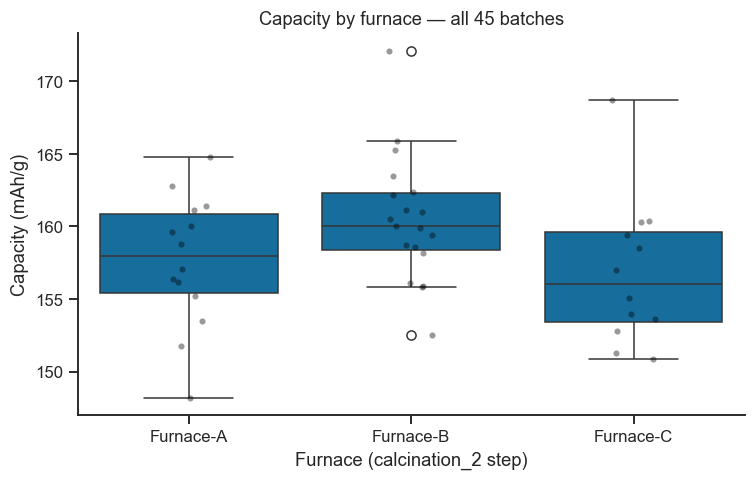

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = ['Furnace-A', 'Furnace-B', 'Furnace-C']
sns.boxplot(data=df_furnace, x='furnace', y='capacity_mAh_g', order=order, ax=ax)
sns.stripplot(data=df_furnace, x='furnace', y='capacity_mAh_g', order=order,
              color='black', alpha=0.4, size=4, ax=ax)
ax.set_xlabel('Furnace (calcination_2 step)')
ax.set_ylabel('Capacity (mAh/g)')
ax.set_title(f'Capacity by furnace — all {len(df_furnace)} batches')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [8]:
fig_px = px.scatter(
    df_furnace, x='calc2_temp', y='capacity_mAh_g', color='furnace',
    hover_data=['sample_id', 'method'],
    category_orders={'furnace': order},
    title='Capacity vs. calcination temperature, coloured by furnace',
    template='plotly_white',
)
fig_px.show()

**Checkpoint / Exercise C**: Redo `summary` with a *two-level*
`groupby(['method', 'furnace'])`. Does the Furnace-C gap hold up within
*both* synthesis methods separately, or mostly within one of them?

<details>
<summary><strong>Suggested answer</strong> (click to reveal)</summary>

```python
df_furnace.groupby(['method', 'furnace'])['capacity_mAh_g'].agg(['count', 'mean', 'std']).round(2)
```

| method | furnace | count | mean | std |
|---|---|---|---|---|
| sol-gel | Furnace-A | 7 | 158.99 | 2.98 |
| sol-gel | Furnace-B | 9 | 161.71 | 5.53 |
| sol-gel | Furnace-C | 7 | 157.73 | 5.75 |
| solid-state reaction | Furnace-A | 7 | 156.29 | 5.57 |
| solid-state reaction | Furnace-B | 10 | 159.37 | 2.84 |
| solid-state reaction | Furnace-C | 5 | 155.58 | 4.07 |

**Yes — the gap holds up within *both* methods separately.** Furnace-C
is the lowest-mean furnace among both the sol-gel rows (157.73, vs.
158.99 and 161.71) and the solid-state-reaction rows (155.58, vs. 156.29
and 159.37). That consistency across two independent sub-groups is
itself evidence the effect isn't just an artefact of one method
happening to draw more Furnace-C batches than the other — worth saying
explicitly live, since it's a genuinely reassuring cross-check ahead of
Section 6.8's recommendation. (Sanity check: the two rows per furnace
recombine into the single-level `summary` table from the previous
cell — e.g. Furnace-A's 7+7=14 samples, weighted mean
(158.99·7 + 156.29·7)/14 = 157.64, matching exactly.)

</details>

> **Take-home message**
>
> - `JOIN` reunites the normalised tables Notebook 3 split apart; `GROUP BY`
>   (or, as used here, `pandas.groupby()` on the joined result) answers
>   "compare X by category" questions — the single most common shape of
>   real database question.
> - Furnace-C's mean capacity (156.8 mAh/g) is clearly lower than
>   Furnace-B's (160.5), but only slightly below Furnace-A's (157.6) —
>   real but *modest*. A plot alone can't tell you whether that's a genuine
>   furnace effect or batch-to-batch noise with only 12–19 samples per
>   furnace — Notebook 8 (Hypothesis Testing) gives you that formal tool.

## 6.5 The Same Investigation in MongoDB

**NoSQL / MongoDB keywords used below**

| Term | Meaning |
|---|---|
| **Document** | One JSON-like record — here, a whole batch with its synthesis history nested inside |
| **Collection** | MongoDB's equivalent of a table — a named group of documents (not required to share a shape) |
| `client[db_name][collection_name]` | Selects/creates a database and collection to work with |
| `coll.insert_many(list_of_dicts)` | Inserts many documents at once |
| **Embedded array** | A list nested directly inside a document (`steps: [...]` below) — MongoDB's alternative to a separate linked table |

Same 45 batches, same "embed the synthesis history inside the sample"
shape as Notebook 3 — now with an `instrument` field on each step.

In [9]:
client = mongomock.MongoClient()   # pymongo.MongoClient(...) against a real server
db = client['materials_lab']
coll = db['cathode_samples']

documents = []
for sample_id, method, calc2_temp, furnace, capacity, efficiency in all_batches:
    documents.append({
        'sample_id': sample_id,
        'material': 'LiFePO4',
        'method': method,
        'atmosphere': 'Ar',
        'steps': [
            {'name': 'mixing',        'instrument': 'Mixer-1',
             'duration_h': 2.0},
            {'name': 'calcination_1', 'instrument': 'Furnace-A',
             'temperature_C': 350, 'duration_h': 4.0},
            {'name': 'calcination_2', 'instrument': furnace,
             'temperature_C': calc2_temp, 'duration_h': 6.0},
        ],
        'results': {
            'capacity_mAh_g': capacity,
            'coulombic_efficiency': efficiency,
        },
    })

coll.insert_many(documents)
print(coll.count_documents({}), 'documents inserted (5 from Notebook 3 + 40 new)')

45 documents inserted (5 from Notebook 3 + 40 new)


**MongoDB aggregation pipeline keywords**

`steps` is an array, so grouping by furnace needs one extra stage
compared to a flat document:

| Stage | Meaning |
|---|---|
| `$unwind: '$steps'` | Turns each document's `steps` array into one pipeline document per step (flattening it) |
| `$match: {...}` | Filters — MongoDB's equivalent of SQL's `WHERE` |
| `$group: {_id: ..., ...}` | Groups by `_id`'s expression and computes aggregates — MongoDB's `GROUP BY` |
| `$sum: 1` | Counts documents in each group |
| `$avg: '$field'` | Averages a field within each group |

Together, `$unwind` → `$match` → `$group` is MongoDB's equivalent of the
`JOIN` + `GROUP BY` from Section 6.4, in one pipeline call.

In [10]:
pipeline = [
    {'$unwind': '$steps'},
    {'$match': {'steps.name': 'calcination_2'}},
    {'$group': {
        '_id': '$steps.instrument',
        'n_batches': {'$sum': 1},
        'mean_capacity': {'$avg': '$results.capacity_mAh_g'},
    }},
]
df_mongo_furnace = (
    pd.DataFrame(list(coll.aggregate(pipeline)))
    .rename(columns={'_id': 'furnace'})
    .sort_values('furnace')
    .reset_index(drop=True)
)
df_mongo_furnace.round(2)

,n_batches,mean_capacity,furnace
0,14,157.64,Furnace-A
1,19,160.48,Furnace-B
2,12,156.83,Furnace-C


Same question, two completely different query languages — they had
better agree. `np.allclose` compares floating-point results without
demanding bit-for-bit equality.

In [11]:
sql_means   = summary['mean'].sort_index()
mongo_means = df_mongo_furnace.set_index('furnace')['mean_capacity'].sort_index()

print('SQL means:  ', np.round(sql_means.values, 2))
print('Mongo means:', np.round(mongo_means.values, 2))
print('SQL and MongoDB agree:', np.allclose(sql_means.values, mongo_means.values, atol=0.01))

SQL means:   [157.64 160.48 156.83]
Mongo means: [157.64 160.48 156.83]
SQL and MongoDB agree: True


## 6.6 When Schema Flexibility Bites

A rushed technician logs one more Furnace-C batch, `batch_50` — but
mistypes the step name as `'clacination_2'`. Nothing in MongoDB's
document model stops this: there is no fixed column list to violate.

In [12]:
sloppy_doc = {
    'sample_id': 'batch_50',
    'material': 'LiFePO4',
    'method': 'sol-gel',
    'atmosphere': 'Ar',
    'steps': [
        {'name': 'mixing',        'instrument': 'Mixer-1',   'duration_h': 2.0},
        {'name': 'calcination_1', 'instrument': 'Furnace-A', 'temperature_C': 350, 'duration_h': 4.0},
        {'name': 'clacination_2', 'instrument': 'Furnace-C', 'temperature_C': 655, 'duration_h': 6.0},  # typo!
    ],
    'results': {'capacity_mAh_g': 158.9, 'coulombic_efficiency': 0.91},
}
coll.insert_one(sloppy_doc)
print(coll.count_documents({}), 'documents now — batch_50 accepted with no error at all.')

df_after = (
    pd.DataFrame(list(coll.aggregate(pipeline)))
    .rename(columns={'_id': 'furnace'})
    .set_index('furnace')
    .sort_index()
)
print()
print('Furnace-C count before batch_50:', int(summary.loc['Furnace-C', 'count']))
print('Furnace-C count after inserting batch_50:', int(df_after.loc['Furnace-C', 'n_batches']))
print('batch_50 is genuinely in the database, but invisible to the exact-match')
print("$match: {'steps.name': 'calcination_2'} stage -- the furnace investigation")
print('silently ran on incomplete data, and nothing in MongoDB flagged it.')

46 documents now — batch_50 accepted with no error at all.

Furnace-C count before batch_50: 12
Furnace-C count after inserting batch_50: 12
batch_50 is genuinely in the database, but invisible to the exact-match
$match: {'steps.name': 'calcination_2'} stage -- the furnace investigation
silently ran on incomplete data, and nothing in MongoDB flagged it.


Is this really "SQL good, MongoDB bad"? Try the *same two mistakes*
against the relational schema.

**Mistake 1 — an invalid reference** (`instrument_id` pointing at an
instrument that doesn't exist): exactly what `FOREIGN KEY` exists to
prevent. `sqlite3.IntegrityError` is the Python exception SQLite raises
when a constraint (foreign key, `NOT NULL`, `PRIMARY KEY` uniqueness, ...)
is violated.

In [13]:
try:
    cur.execute(
        "INSERT INTO synthesis_steps "
        "(sample_id, step_order, step_name, temperature_C, duration_h, instrument_id) "
        "VALUES ('batch_09', 4, 'calcination_2', 655, 6.0, 40)"   # instrument_id 40 doesn't exist
    )
    conn.commit()
except sqlite3.IntegrityError as e:
    print('Rejected immediately:', e)

Rejected immediately: FOREIGN KEY constraint failed


**Mistake 2 — the same spelling typo**: not a foreign-key problem, just
a plain text column with no constraint on which strings are valid.

In [14]:
cur.execute(
    "INSERT INTO synthesis_steps "
    "(sample_id, step_order, step_name, temperature_C, duration_h, instrument_id) "
    "VALUES ('batch_09', 5, 'clacination_2', 655, 6.0, 4)"
)
conn.commit()
print('Accepted without complaint -- step_name has no CHECK constraint, so plain SQLite')
print('is just as blind to this specific typo as MongoDB was.')

Accepted without complaint -- step_name has no CHECK constraint, so plain SQLite
is just as blind to this specific typo as MongoDB was.


> **Take-home message**
>
> The real lesson isn't "SQL enforces everything, MongoDB enforces
> nothing" — it's that **each database only enforces exactly what you told
> it to.** `FOREIGN KEY` protects referential integrity in SQL; MongoDB has
> no native equivalent and needs application-level validation for the same
> guarantee. Neither database protects against a free-text typo unless you
> explicitly add something to catch it — a `CHECK` constraint (SQL) or a
> validation function before every `insert_one` (MongoDB).

## 6.7 *Going Further*: Indexing and Query Performance

45 rows is nothing to search — a database just scans the whole table. A
real lab accumulates thousands of rows; at scale, *how* a database finds
matching rows starts to matter.

| Term | Meaning |
|---|---|
| **Index** | A separate, sorted structure the database can binary-search instead of scanning row by row |
| `CREATE INDEX name ON table(col)` | Builds an index on `col` |
| `EXPLAIN QUERY PLAN` | Asks SQLite to show *how* it will execute a query — `SCAN` (checks every row) vs. `SEARCH ... USING INDEX` (binary search) |
| **Selectivity** | How many distinct values a column has, relative to row count — indexing pays off far more for a high-selectivity column |

Simulate scale directly: 200,000 rows, then time a lookup before and
after adding an index.

In [15]:
import time

conn2 = sqlite3.connect(':memory:')
conn2.execute(
    'CREATE TABLE big_steps (id INTEGER PRIMARY KEY, sample_id TEXT, '
    'instrument_id INTEGER, capacity_mAh_g REAL)'
)

n_big = 200_000
big_instrument_ids = rng.integers(1, 5, size=n_big)
big_capacity       = rng.normal(160, 8, size=n_big)

cur2 = conn2.cursor()
cur2.executemany(
    'INSERT INTO big_steps (sample_id, instrument_id, capacity_mAh_g) VALUES (?, ?, ?)',
    [(f'sim_{i}', int(iid), float(cap))
     for i, (iid, cap) in enumerate(zip(big_instrument_ids, big_capacity))],
)
conn2.commit()
print(f'{n_big:,} synthetic step rows inserted (simulating years of accumulated lab data).')

200,000 synthetic step rows inserted (simulating years of accumulated lab data).


In [16]:
n_repeat = 20
target = 'sim_150000'   # a single, specific row -- the realistic case: "look up this one sample"

t0 = time.perf_counter()
for _ in range(n_repeat):
    cur2.execute('SELECT capacity_mAh_g FROM big_steps WHERE sample_id = ?', (target,)).fetchone()
t_no_index = (time.perf_counter() - t0) / n_repeat

cur2.execute('CREATE INDEX idx_sample_id ON big_steps(sample_id)')

t0 = time.perf_counter()
for _ in range(n_repeat):
    cur2.execute('SELECT capacity_mAh_g FROM big_steps WHERE sample_id = ?', (target,)).fetchone()
t_with_index = (time.perf_counter() - t0) / n_repeat

print(f'Without index: {t_no_index*1e6:8.1f} µs/query  (average of {n_repeat} runs)')
print(f'With index:    {t_with_index*1e6:8.1f} µs/query  (average of {n_repeat} runs)')
print(f'Speedup:       {t_no_index/t_with_index:.1f}x')

Without index:   5807.7 µs/query  (average of 20 runs)
With index:         5.9 µs/query  (average of 20 runs)
Speedup:       980.2x


In [17]:
plan = cur2.execute(
    "EXPLAIN QUERY PLAN SELECT capacity_mAh_g FROM big_steps WHERE sample_id = 'sim_150000'"
).fetchall()
for row in plan:
    print(row)
print()
print('SEARCH ... USING INDEX confirms SQLite used the B-tree index instead of scanning')
print('all 200,000 rows -- before CREATE INDEX, this would instead read \'SCAN big_steps\'.')

(3, 0, 62, 'SEARCH big_steps USING INDEX idx_sample_id (sample_id=?)')

SEARCH ... USING INDEX confirms SQLite used the B-tree index instead of scanning
all 200,000 rows -- before CREATE INDEX, this would instead read 'SCAN big_steps'.


> **Take-home message**
>
> Indexing trades a small amount of storage and slower *writes* for much
> faster *reads* on the indexed column. The speedup above depends on
> **selectivity**: `sample_id` has 200,000 distinct values, so an index
> narrows the search almost immediately; a column like `instrument_id`
> (only 4 distinct values) would benefit far less. `mongomock` has no real
> index structures — a real MongoDB server's `db.collection.create_index()`
> gives the same benefit, `.explain()` its equivalent of `EXPLAIN QUERY
> PLAN`.

## 6.8 Summary: What to Do About Furnace-C

Furnace-C's mean capacity (156.8 mAh/g) is clearly below Furnace-B's
(160.5) and slightly below Furnace-A's (157.6) — real but modest, and
confirmed two independent ways (SQL and MongoDB). This is **suggestive,
not proof**: Notebook 8 (Hypothesis Testing) is where "looks a bit lower"
becomes "is statistically different."

**Honest recommendation**: flag Furnace-C for recalibration regardless
(its calibration date alone justifies that), and re-run the comparison
with a proper hypothesis test before treating the gap as confirmed.

| What today added | Where |
|---|---|
| Realistic *scale* (45 batches, not 5) | 6.2 |
| The `instruments` table, built and linked live | 6.3 |
| A cross-checked SQL + MongoDB investigation | 6.4–6.5 |
| An honest look at what each schema enforces | 6.6 |
| What changes at real-lab scale | 6.7 |

## Keyword Reference — Today in One Table

| SQL | Meaning | MongoDB | Meaning |
|---|---|---|---|
| Table | Fixed-column collection of rows | Collection | Free-form group of documents |
| Row | One record | Document | One JSON-like record |
| `CREATE TABLE` | Define columns upfront | *(none)* | Documents define their own shape |
| `PRIMARY KEY` | Unique row identifier | `_id` | Unique document identifier (automatic) |
| `FOREIGN KEY` / `REFERENCES` | Enforced link to another table | *(none — app-level only)* | No native referential integrity |
| `JOIN ... ON` | Reunite related tables | `$unwind` + `$match` | Flatten + filter nested arrays |
| `GROUP BY` | Aggregate by category | `$group` | Aggregate by category |
| `WHERE` | Filter rows | `$match` | Filter documents |
| `CREATE INDEX` | Speed up lookups on a column | `create_index()` | Same idea, same trade-off |
| `sqlite3.IntegrityError` | Raised on constraint violation | *(no equivalent — nothing to violate)* | |

## Coming Up

**Next**: Live Tutorial 2 — Querying and Plotting Real NOMAD Data
`chapters/02_data_handling/07_nomad_api_live_tutorial.ipynb`

Same "query, build a DataFrame, plot" workflow — this time against the
real, public NOMAD repository over the internet, no server of your own
required.

## Questions?

**Workshop 1 — SQL & NoSQL in Practice**

1KB570 — Data Handling, Statistics & Design of Experiments for Materials Scientists
<br>
Department of Chemistry – Ångström, Uppsala University